# Consigna

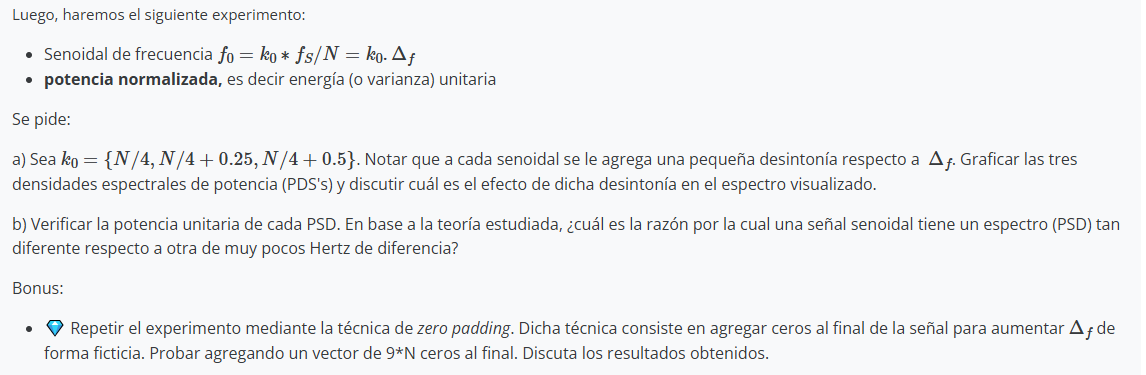

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(Pn = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(Pn = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance Pn and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(Pn), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_sig = np.mean(xx**2)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

## Prueba 1:
Se desea ver qué ocurre si los valores a graficar no coinciden exactamente con ningún "bin" de frecuencia y, por el contrario, se encuentran en el medio. Para ello se realizará una prueva con 3 senoidales de distinta frecuencia. La primera estará en un bin exacto y las otras dos no. 

In [60]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
k0 = np.array([N/4, N/4 + .25, N/4 + .5])
freqs = k0 * delta_f   # Freq

##### Funciones
xx = []
for freq in freqs:
    xx_aux, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
    xx.append(xx_aux)

t = np.arange(stop=N/fs, step=1/fs).reshape(-1,1)

print(f"Frecuencias a utilizar: {freqs.flatten()} Hz")
print(f"Resolución espectral: {delta_f} Hz")

Frecuencias a utilizar: [500.   500.25 500.5 ] Hz
Resolución espectral: 1.0 Hz


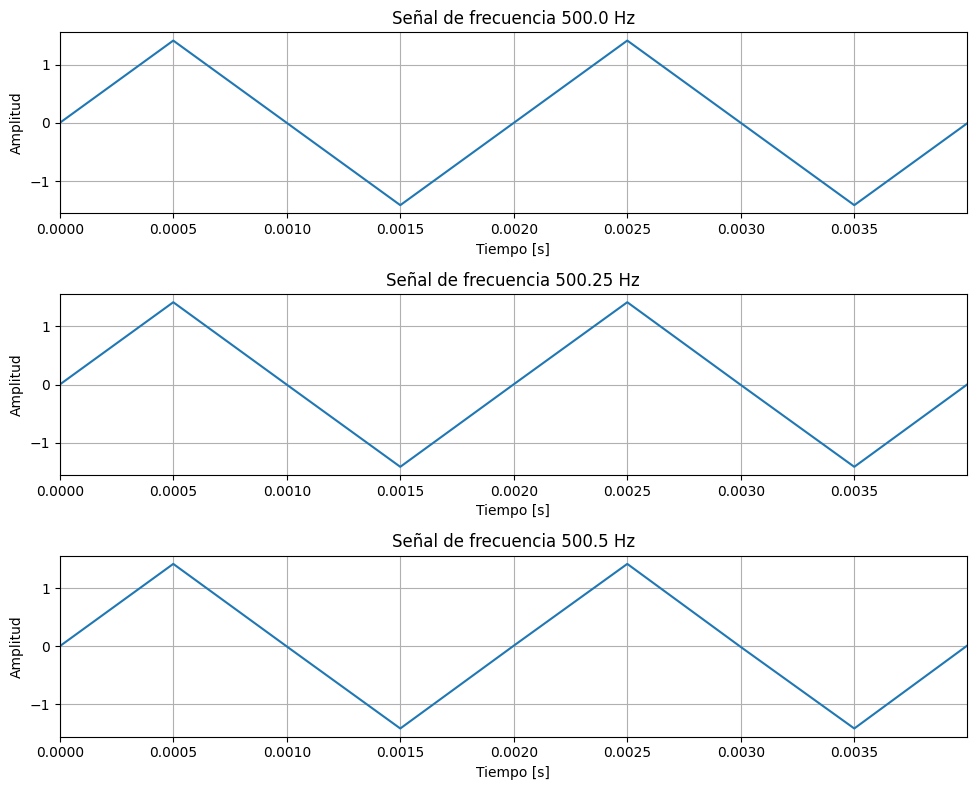

In [61]:
##### Gráficos
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, xx[0])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[0]} Hz")
plt.tight_layout()
plt.grid()

# Señal de Error #####
plt.subplot(3,1,2)
plt.plot(t, xx[1])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[1]} Hz")
plt.tight_layout()
plt.grid()


plt.subplot(3,1,3)
plt.plot(t, xx[2])
plt.xlim(0,2/freqs[2])

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[2]} Hz")
plt.tight_layout()
plt.grid()

plt.show()


En las señales temporales apenas se nota diferencia, puesto que su frecuencia es muy parecida.

**Gráfico de las 3 FFT**

Se muestra el espectro completo para que se observe claramente el efecto del desparramo de potencia

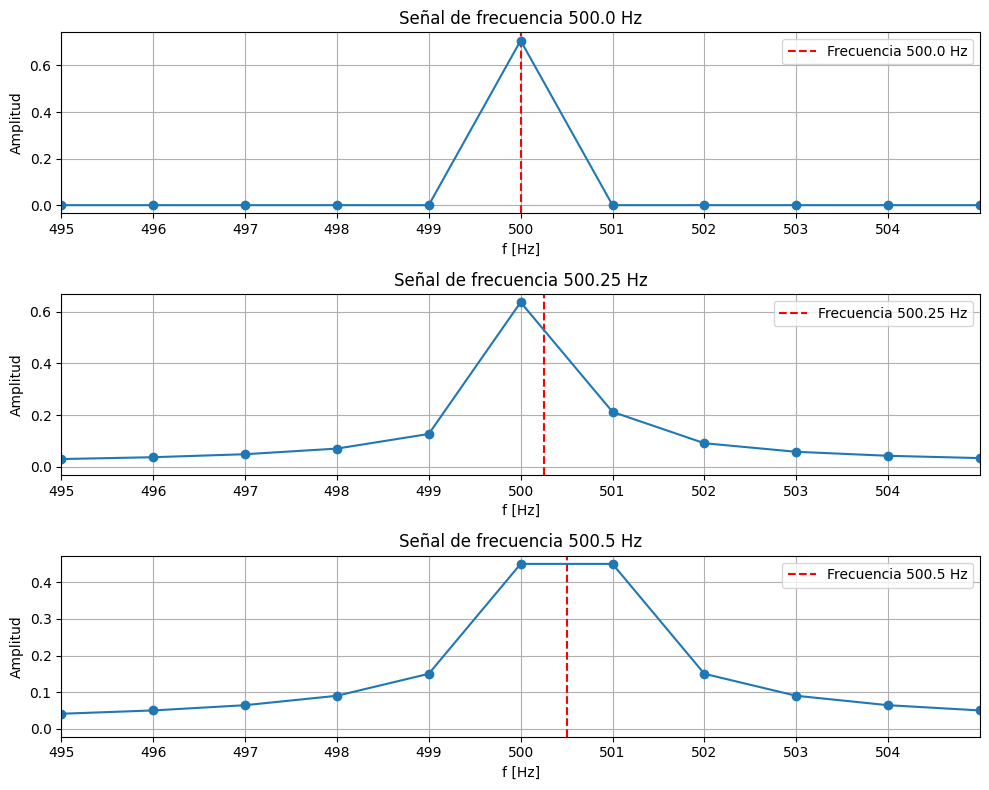

In [62]:
xx_fft = [np.fft.fft(x, axis=0)/len(x) for x in xx]
abs_xx_fft = [np.abs(fft) for fft in xx_fft]

plt.figure(figsize=(10,8))

for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(abs_xx_fft[i], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz")
    plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

Se observa que las señales, al tener energía entre 2 bins, comienzan a desparramar la misma a los bins cercanos. Esto se conoce como "spectral leakage" y ocurre cuando hay energía entre 2 en una frecuencia intermedia entre las muestras de la DFT.

El peor caso aparece en la 3er señal, donde la energía se encuentra exactamente en el medio de 2 bins.

Lo que antes era una delta ahora es una curva de valores cercanos al original.

A continuación, se muestran los mismos gráficos pero en dB. 

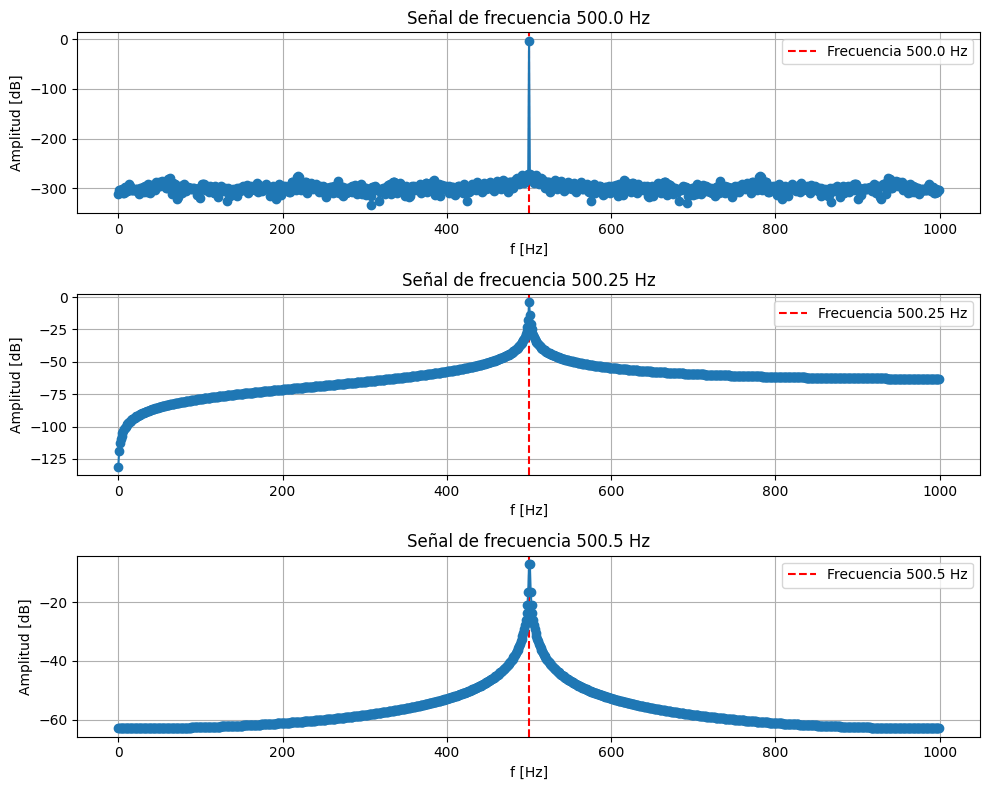

Valor de FFT en frecuencia 500.0 Hz: 
1. señal 1: [-3.01029996] dB
1. señal 2: [-3.92580893] dB
1. señal 3: [-6.93270464] dB


In [63]:
plt.figure(figsize=(10,8))

for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(20*np.log10(abs_xx_fft[i])[0:N//2], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud [dB]")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz")
    #plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    #plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

print(f"Valor de FFT en frecuencia {freqs[0]} Hz: ")
print(f"1. señal 1: {20*np.log10(abs_xx_fft[0])[int(freqs[0])]} dB")
print(f"1. señal 2: {20*np.log10(abs_xx_fft[1])[int(freqs[0])]} dB")
print(f"1. señal 3: {20*np.log10(abs_xx_fft[2])[int(freqs[0])]} dB")

Se puede observar que en dB la diferencia es mucho más notoria, pasando de un piso de ruido de -300dB (prácticamente -infinito) a un piso de ruido de -60dB solo por tener energía entre 2 bins. 

Para solucionar este problema se colocan "ventanas" Estas son añadidas a la función y suelen mejorar su resultado a los extremos, aunque a veces empeoren otros parámetros (aumentando el lóbulo generado por la delta original por ejemplo)

Es importante aclarar que no usar ninguna ventana, en realidad corresponde a la ventana rectangular donde todas sus muestras valen 1.

## Prueba 2: Ventaneo Hann

En las pruebas anteriores se estuvo utilizando una ventana con forma de pulso unitario o rectangular (sin ventana, tomando las muestras directamete).
El algoritmo de DFT periodiza la señal que se está evaluando, por lo tanto, se generan discontinuidades si no se muestrean periodos exactos y completos de la señal (otra forma de ver el spectral leakage).

A continuación, se realizará el mismo tratamiento anterior pero con ventana HANN

In [64]:
from scipy import signal

##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
k0 = np.array([N/4, N/4 + .25, N/4 + .5])

freqs = k0 * delta_f   # Freq

##### Funciones
xx = []
for freq in freqs:
    xx_aux, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
    xx.append(xx_aux)

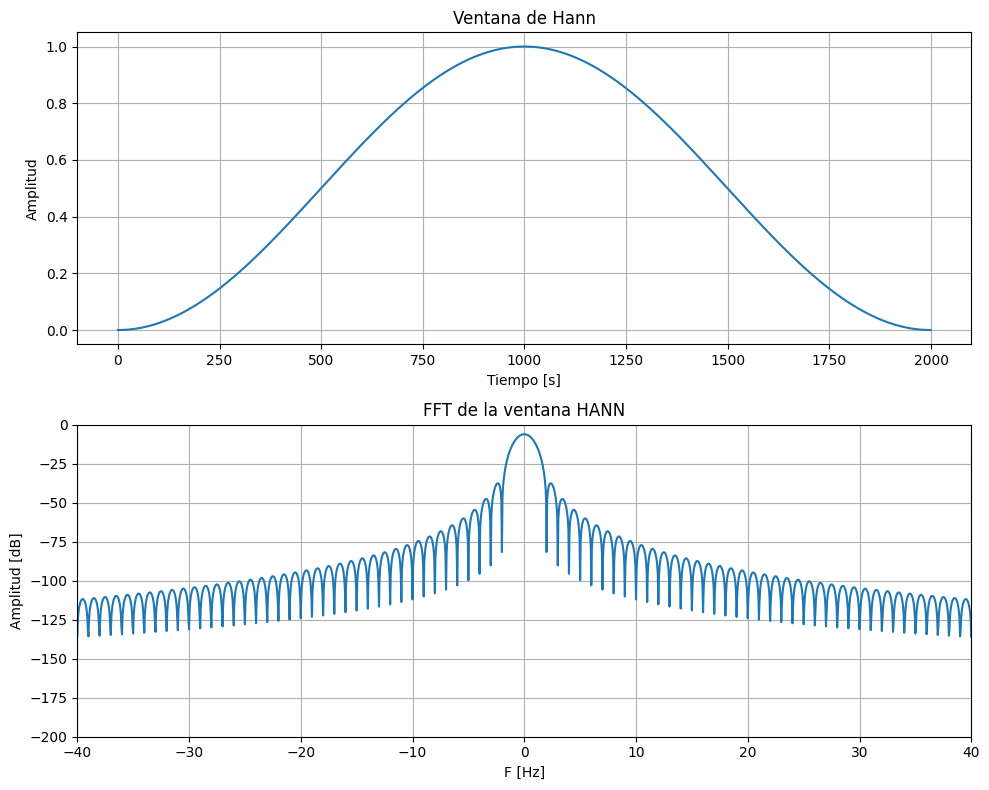

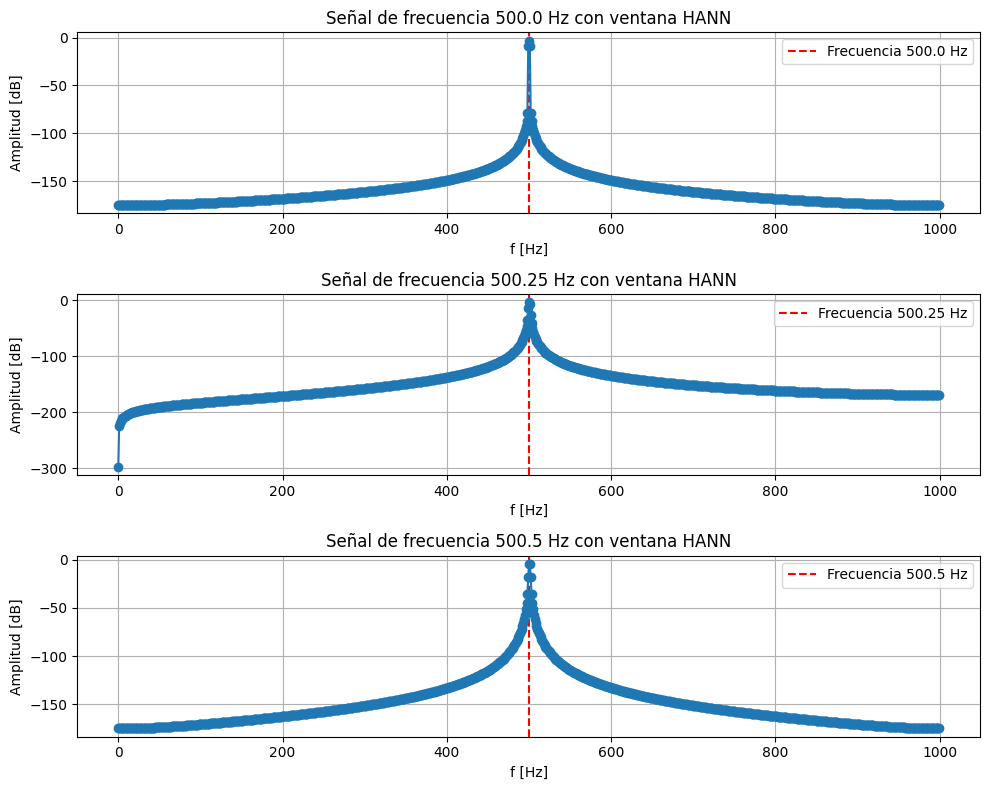

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.36 dB
Valor en 500 Hz para F=500.5 Hz: -4.43 dB


In [65]:
##### Aplicacion de ventana
window = signal.windows.hann(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

##### Gráfico de ventana
len_fft_window = 20*N       # Solo a nivel visual, se usa zero-padding. Se explicará más adelante. Mejora la resolución.
fft_window = np.fft.fft(window, n=len_fft_window, axis=0)/len(window)
fft_window = np.concatenate([fft_window[len_fft_window//2:], fft_window[:len_fft_window//2]])
fft_window_abs = mod_db(fft_window)
ff = np.arange(-N//2, N//2, delta_f * N/len_fft_window) 

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(window)
plt.title("Ventana de Hann")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2,1,2)
plt.plot(ff, fft_window_abs)
plt.xlim(-40, 40)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana HANN")
plt.tight_layout()
plt.grid()
plt.show()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos FFT
plt.figure(figsize=(10,8))
for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(abs_xx_fft[i][0:N//2], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud [dB]")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz con ventana HANN")
    #plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    #plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][int(freqs[0])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][int(freqs[1])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][int(freqs[2])][0]:.2f} dB")


Se observa un piso de ruido mejor para las señales con spectral leakage y pero para la señal perfecta.
Los valores en f0 se aproximan mucho más unos a otros al igual que los pisos de ruido.

## Prueba 3: Ventananeo Hamming

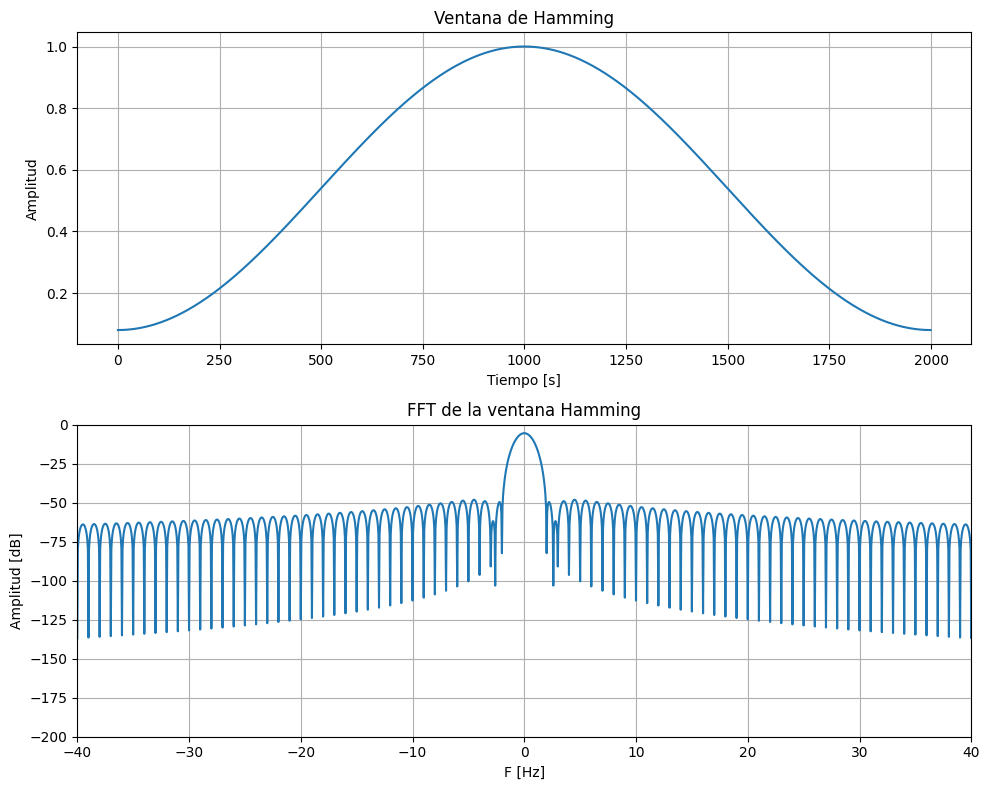

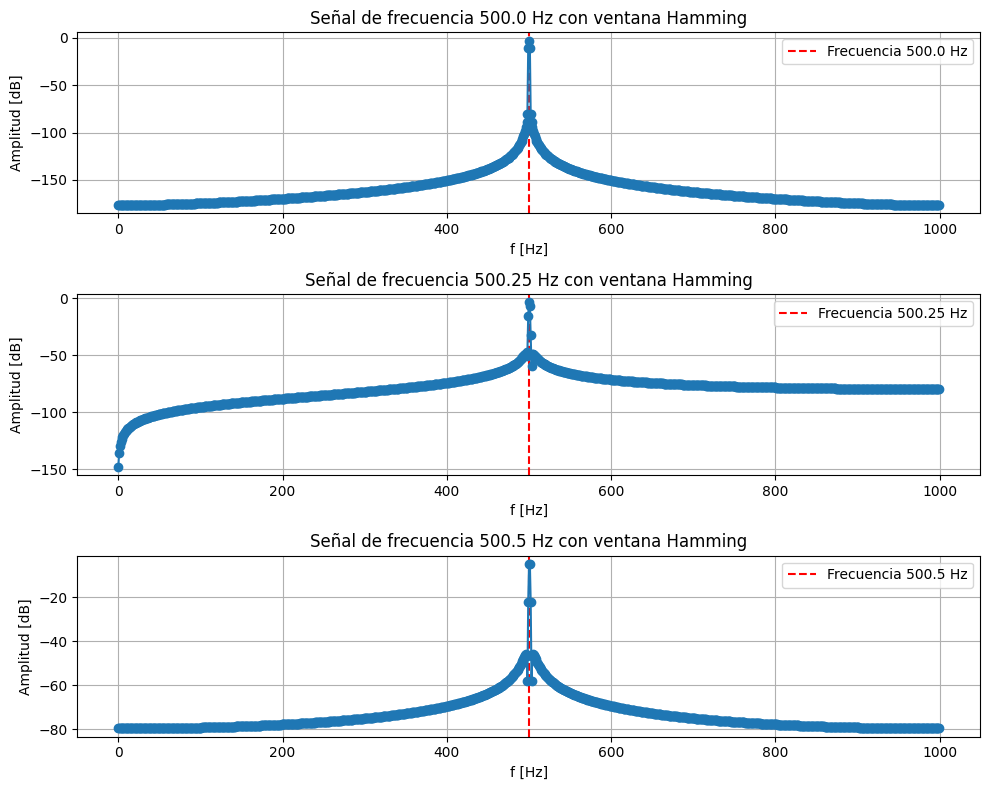

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.44 dB
Valor en 500 Hz para F=500.5 Hz: -4.76 dB


In [66]:
##### Aplicacion de ventana
window = signal.windows.hamming(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

##### Gráfico de ventana
len_fft_window = 20*N       # Solo a nivel visual, se usa zero-padding. Se explicará más adelante. Mejora la resolución.
fft_window = np.fft.fft(window, n=len_fft_window, axis=0)/len(window)
fft_window = np.concatenate([fft_window[len_fft_window//2:], fft_window[:len_fft_window//2]])
fft_window_abs = mod_db(fft_window)
ff = np.arange(-N//2, N//2, delta_f * N/len_fft_window) 

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(window)
plt.title("Ventana de Hamming")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2,1,2)
plt.plot(ff, fft_window_abs)
plt.xlim(-40, 40)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana Hamming")
plt.tight_layout()
plt.grid()
plt.show()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos FFT
plt.figure(figsize=(10,8))
for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(abs_xx_fft[i][0:N//2], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud [dB]")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz con ventana Hamming")
    #plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    #plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][int(freqs[0])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][int(freqs[1])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][int(freqs[2])][0]:.2f} dB")

## Prueba 4: Ventaneo Blackmann-Harris

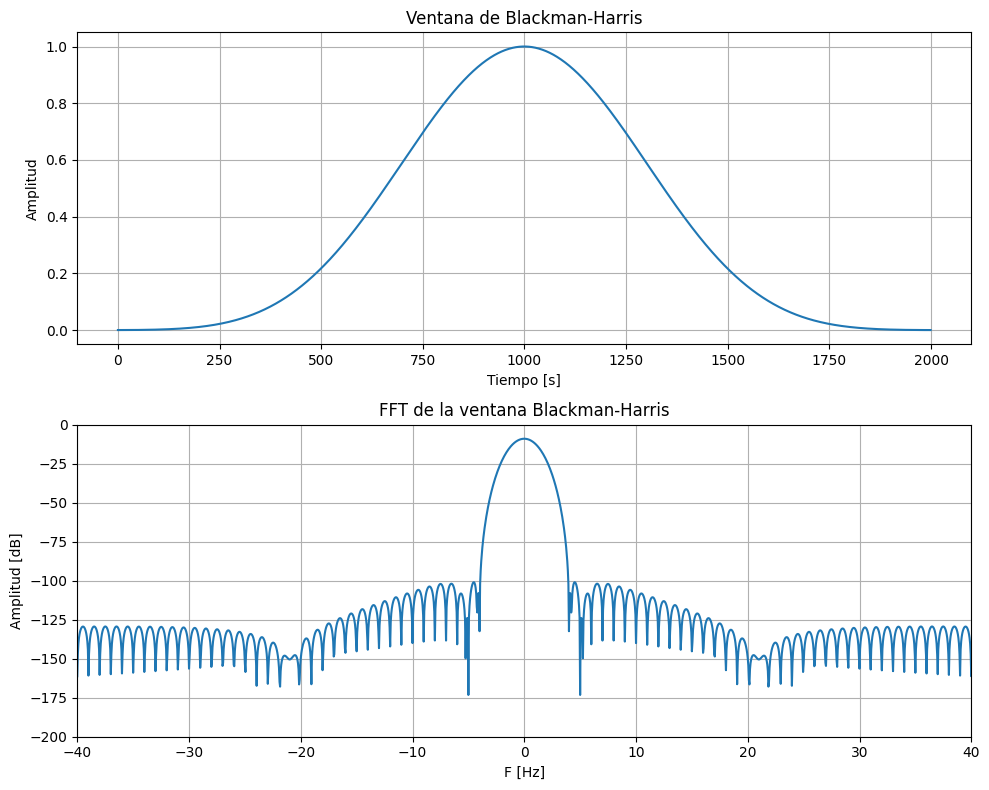

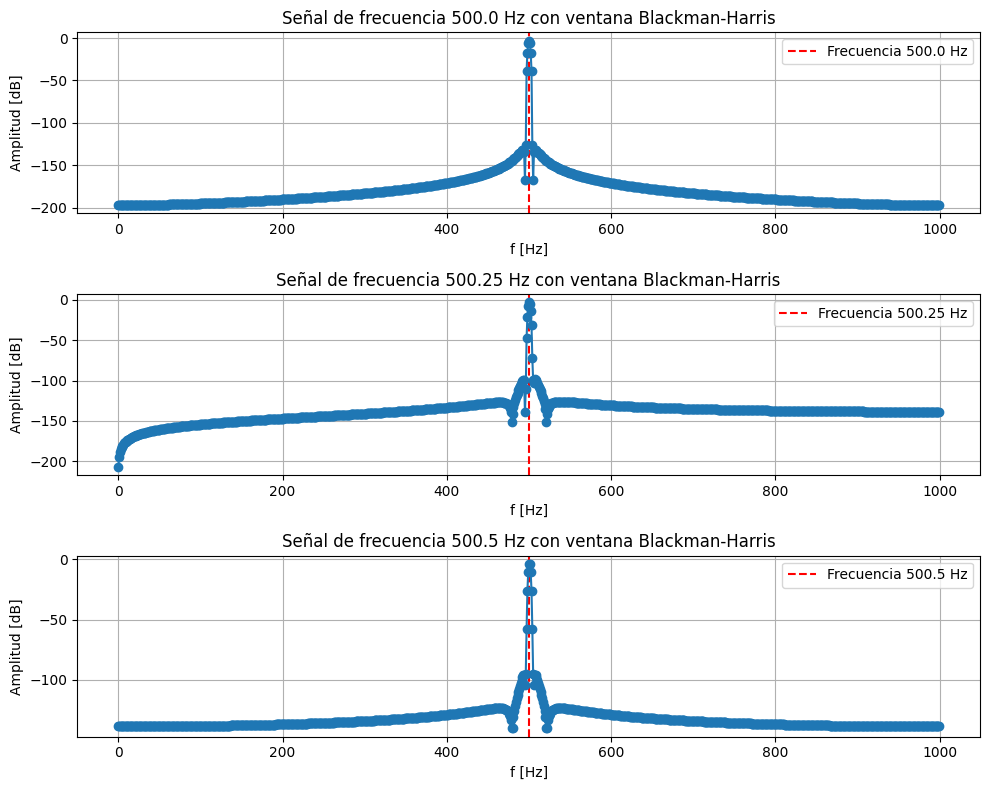

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.22 dB
Valor en 500 Hz para F=500.5 Hz: -3.84 dB


In [67]:
##### Aplicacion de ventana
window = signal.windows.blackmanharris(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

##### Gráfico de ventana
len_fft_window = 20*N       # Solo a nivel visual, se usa zero-padding. Se explicará más adelante. Mejora la resolución.
fft_window = np.fft.fft(window, n=len_fft_window, axis=0)/len(window)
fft_window = np.concatenate([fft_window[len_fft_window//2:], fft_window[:len_fft_window//2]])
fft_window_abs = mod_db(fft_window)
ff = np.arange(-N//2, N//2, delta_f * N/len_fft_window) 

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(window)
plt.title("Ventana de Blackman-Harris")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2,1,2)
plt.plot(ff, fft_window_abs)
plt.xlim(-40, 40)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana Blackman-Harris")
plt.tight_layout()
plt.grid()
plt.show()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos FFT
plt.figure(figsize=(10,8))
for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(abs_xx_fft[i][0:N//2], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud [dB]")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz con ventana Blackman-Harris")
    #plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    #plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][int(freqs[0])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][int(freqs[1])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][int(freqs[2])][0]:.2f} dB")

## Prueba 5: ventaneo Flattop

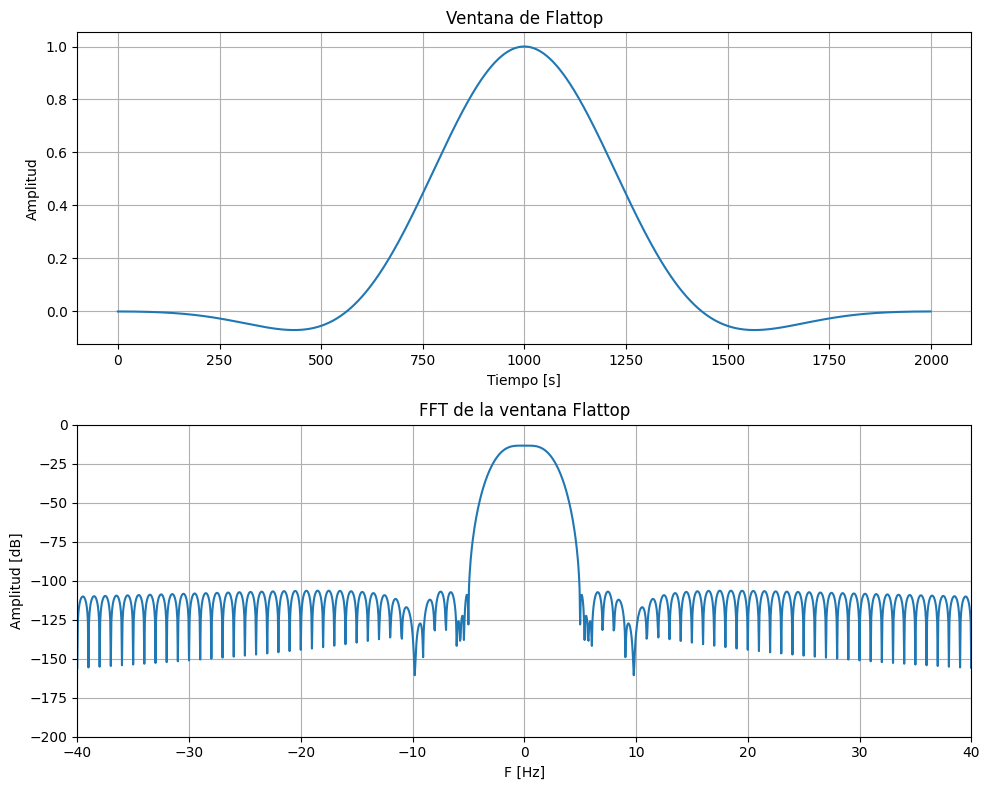

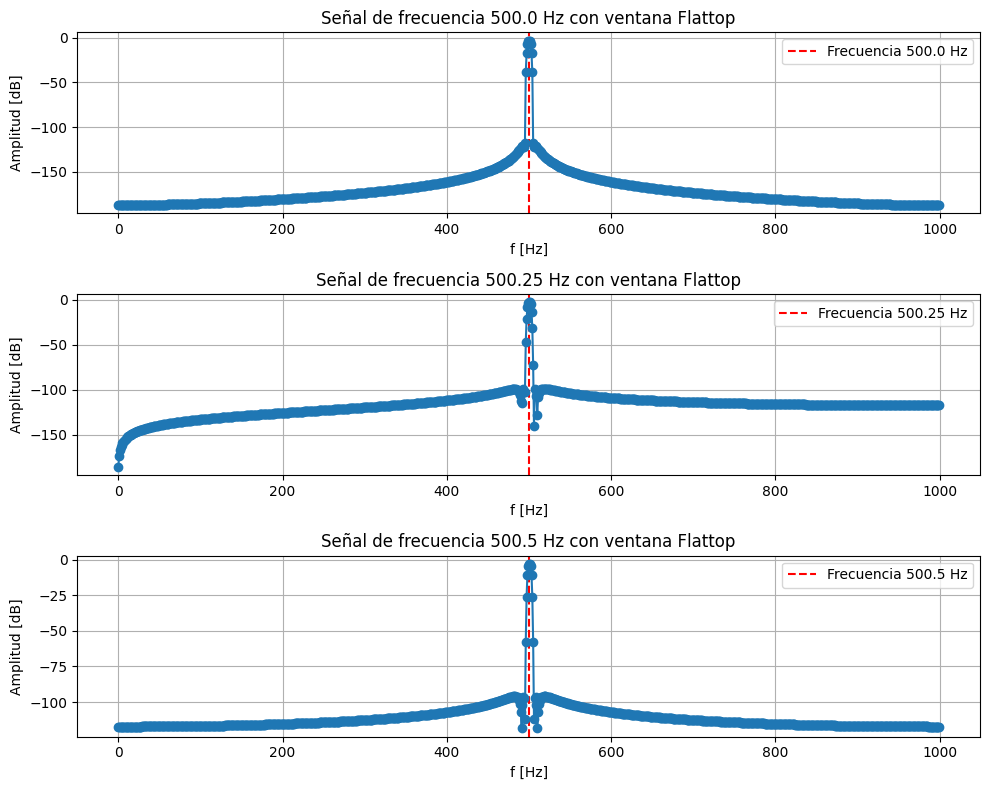

Valor en 500 Hz para F=500 Hz: -3.01 dB
Valor en 500 Hz para F=500.25 Hz: -3.01 dB
Valor en 500 Hz para F=500.5 Hz: -3.02 dB


In [68]:
## Aplicacion de ventana
window = signal.windows.flattop(N).reshape(-1,1)
err_window = window.mean()
xx_windowed = [x * window for x in xx]

##### Gráfico de ventana
len_fft_window = 20*N       # Solo a nivel visual, se usa zero-padding. Se explicará más adelante. Mejora la resolución.
fft_window = np.fft.fft(window, n=len_fft_window, axis=0)/len(window)
fft_window = np.concatenate([fft_window[len_fft_window//2:], fft_window[:len_fft_window//2]])
fft_window_abs = mod_db(fft_window)
ff = np.arange(-N//2, N//2, delta_f * N/len_fft_window) 

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(window)
plt.title("Ventana de Flattop")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2,1,2)
plt.plot(ff, fft_window_abs)
plt.xlim(-40, 40)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana Flattop")
plt.tight_layout()
plt.grid()
plt.show()

##### FFT
xx_fft = [np.fft.fft(x, axis=0)/(len(x)*err_window) for x in xx_windowed]
abs_xx_fft = [mod_db(fft) for fft in xx_fft]

##### Gráficos FFT
plt.figure(figsize=(10,8))
for i in range(len(freqs)):
    plt.subplot(3,1,i+1)
    plt.axvline(x=freqs[i], color='r', linestyle='--', label=f"Frecuencia {freqs[i]} Hz")
    plt.plot(abs_xx_fft[i][0:N//2], "-o")
    plt.xlabel("f [Hz]")
    plt.ylabel("Amplitud [dB]")
    plt.title(f"Señal de frecuencia {freqs[i]} Hz con ventana Flattop")
    #plt.xticks(np.arange(.99*freqs[0], 1.01*freqs[0], delta_f))
    #plt.xlim(.99*freqs[0], 1.01*freqs[0])
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

print(f"Valor en 500 Hz para F=500 Hz: {abs_xx_fft[0][int(freqs[0])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.25 Hz: {abs_xx_fft[1][int(freqs[1])][0]:.2f} dB")
print(f"Valor en 500 Hz para F=500.5 Hz: {abs_xx_fft[2][int(freqs[2])][0]:.2f} dB")

Luego de realizar la misma prueba con 4 ventanas distintas se puede observar que el ventaneo es una técnica que nos permite mejorar el piso de ruido cuando la señal presenta spectral leakage pero lo empeora cuando la señal no lo posee. Se podría decir que nos coloca un piso de ruido que suele ser comparable a todas las señales, sin importar si se encontraban fuera de bin o no.

Esto nos permite medir con mayor facilidad señales reales donde la frecuencia muy probablemente no se encuentre en un valor exacto de K.

También se puede ver que no todas las ventanas responden igual, y que incluso llegan a deformar nuestra señal original. Esto es importante porque nos permite definir cuándo usar una ventana u otra. Algunas ensanchan más el espectro, permitiendo que la energía llegue con su valor correcto a un bin cercano. Eso nos permitiría medir mucho mejor energía, pero no la frecuencia ya que las señales estarán más expandidas y su frecuencia real ya no será tan clara.

## Prueba 6: zero-padding

El zero-padding consiste en añadir más muestras con valor 0. Esto en principio no añade información de ningún tipo.
Sin embargo, la resolución espectral dependía del número de muestras y añadir ceros aumenta ese valor. Eso provoca un efecto de interpolación que suaviza la señal, añadiendo más puntos. Se mejora la resolución, pero la señal sigue siendo la misma.

A continuación se realizará la demostración de añadir zero padding a la señal con el mayor spectral leakage que teníamos anteriormente.

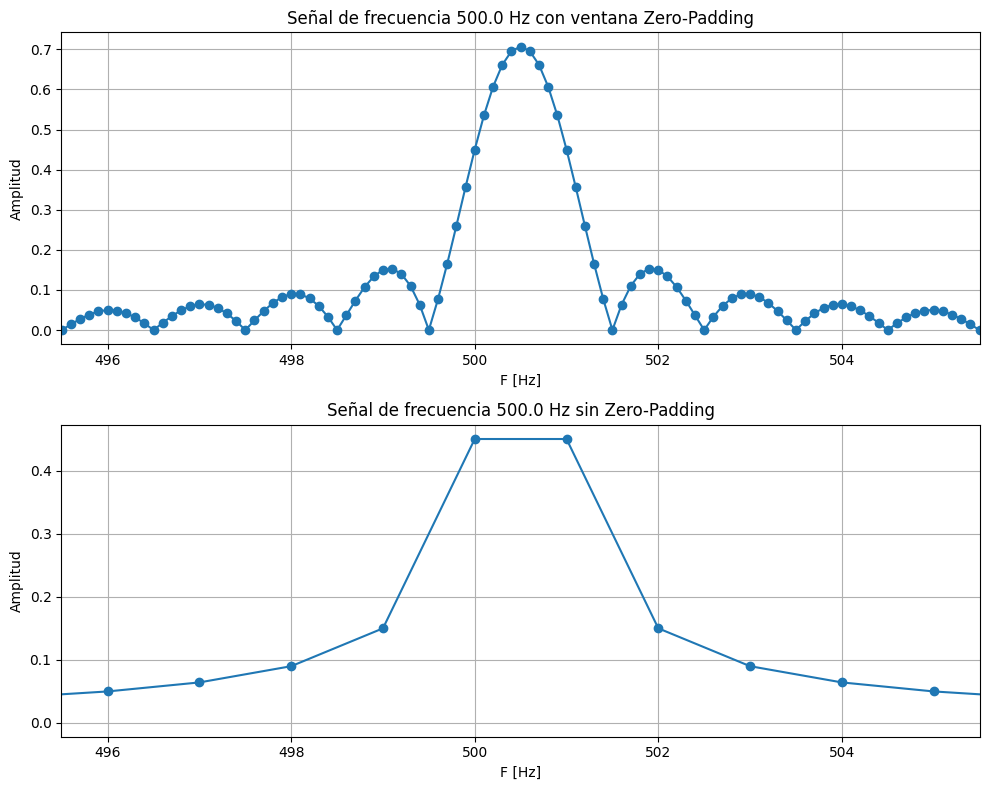

In [73]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo
zeros = 9*N

delta_f = fs/N
freq = N/4 + .5   # Freq

##### Funciones
xx, _ = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)

## FFT
N_FFT = N + zeros
xx_fft_zp = np.fft.fft(xx, axis=0, n=N_FFT )/N
xx_fft = np.fft.fft(xx, axis=0 )/N

abs_xx_fft = np.abs(xx_fft) 
abs_xx_fft_zp = np.abs(xx_fft_zp)

ff = np.arange(0, fs//2, delta_f)
ff = ff.reshape(-1,1)
ff_zp = np.arange(0, fs//2, delta_f * N/N_FFT) 
ff_zp = ff_zp.reshape(-1,1)


plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(ff_zp, abs_xx_fft_zp[:len(abs_xx_fft_zp)//2], '-o')
plt.xlim(0.99*freq, 1.01*freq)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[0]} Hz con ventana Zero-Padding")
plt.tight_layout()
plt.grid()


plt.subplot(2,1,2)
plt.plot(ff,abs_xx_fft[:len(abs_xx_fft)//2], '-o')
plt.xlim(0.99*freq, 1.01*freq)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud")
plt.title(f"Señal de frecuencia {freqs[0]} Hz sin Zero-Padding")
plt.tight_layout()
plt.grid()

plt.show()

Al aumentar la resolución se puede observar que en realidad, no estabamos graficando solo una delta. También se estaba graficando la sinc correspondiente a la ventana rectangular (la correspondiente a no usar ninguna ventana).

Se observa a continuación otro ejemplo muy visual del uso de zero-padding, graficando las FFT de otras ventanas (Esto fue realizado en los gráficos de ventanas anteriores para poder visualizar correctamente las FFT). 

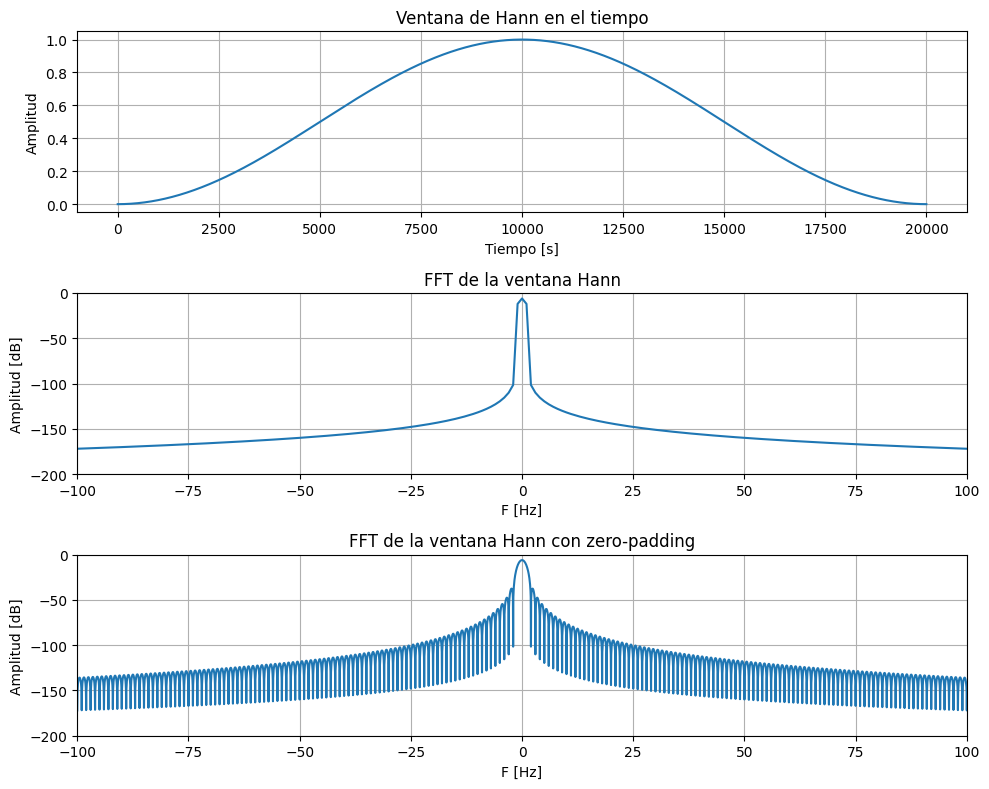

In [70]:
##### Ventana
N = 20000
N_FFT_ZP = 20*N       

window = signal.windows.hann(N)

##### Gráfico de ventana
fft_window = np.fft.fft(window)/N
fft_window = np.concatenate([fft_window[N//2:], fft_window[:N//2]])
fft_window_abs = mod_db(fft_window)

fft_window_zp = np.fft.fft(window, n=N_FFT_ZP)/N
fft_window_zp = np.concatenate([fft_window_zp[N_FFT_ZP//2:], fft_window_zp[:N_FFT_ZP//2]])
fft_window_zp_abs = mod_db(fft_window_zp)

ff = np.arange(-N//2, N//2)
ff_zp = np.arange(-N//2, N//2, N/N_FFT_ZP) 

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(window)
plt.title("Ventana de Hann en el tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(3,1,2)
plt.plot(ff, fft_window_abs)
plt.xlim(-100, 100)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana Hann")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(ff_zp, fft_window_zp_abs)
plt.xlim(-100, 100)
plt.ylim(-200, 0)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title(f"FFT de la ventana Hann con zero-padding")
plt.tight_layout()
plt.grid()
plt.show()


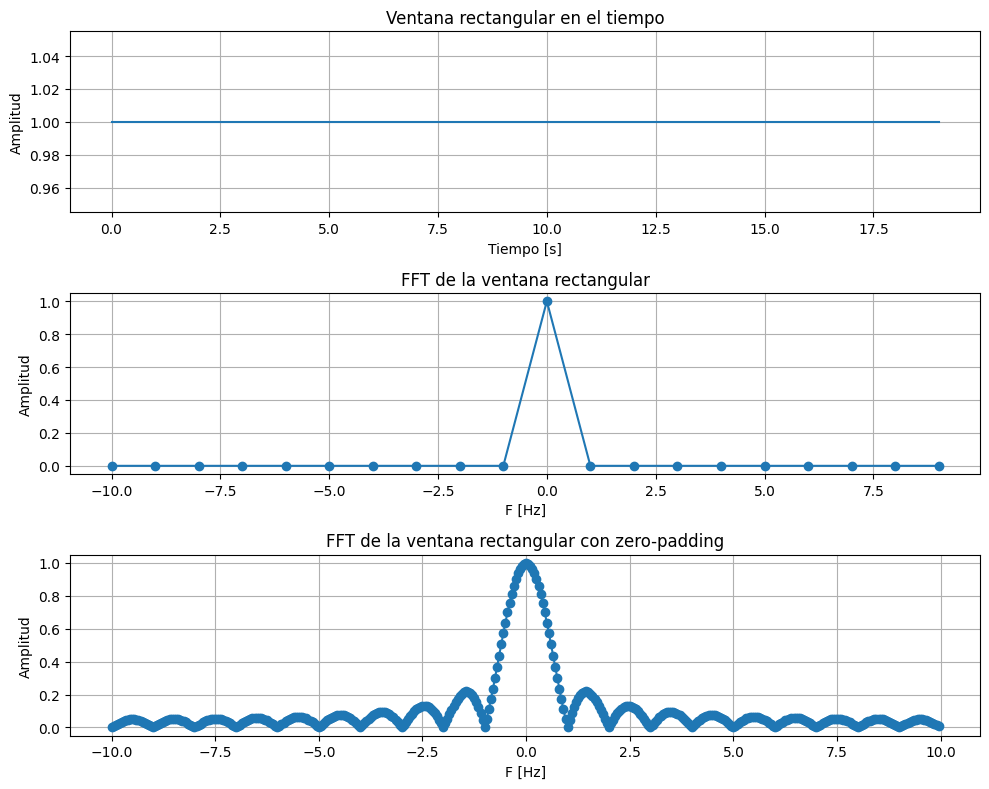

In [71]:
##### Ventana
N = 20
N_FFT_ZP = 20*N       

window = np.ones(N)

##### Gráfico de ventana
fft_window = np.fft.fft(window)/N
fft_window = np.concatenate([fft_window[N//2:], fft_window[:N//2]])
fft_window_abs = np.abs(fft_window)

fft_window_zp = np.fft.fft(window, n=N_FFT_ZP)/N
fft_window_zp = np.concatenate([fft_window_zp[N_FFT_ZP//2:], fft_window_zp[:N_FFT_ZP//2]])
fft_window_zp_abs = np.abs(fft_window_zp)

ff = np.arange(-N//2, N//2)
ff_zp = np.arange(-N_FFT_ZP//2, N_FFT_ZP//2) * N/N_FFT_ZP

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(window)
plt.title("Ventana rectangular en el tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(3,1,2)
plt.plot(ff, np.maximum(fft_window_abs, -500), '-o')
#plt.xlim(-100, 100)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud")
plt.title(f"FFT de la ventana rectangular")
plt.tight_layout()
plt.grid()

plt.subplot(3,1,3)
plt.plot(ff_zp, fft_window_zp_abs, '-o')
#plt.xlim(-100, 100)
plt.xlabel("F [Hz]")
plt.ylabel("Amplitud")
plt.title(f"FFT de la ventana rectangular con zero-padding")
plt.tight_layout()
plt.grid()
plt.show()


Se observa que, sin zero-padding, la ventana rectangular responde como una señal de continua cuya transformada de fourier es una delta. Si se añaden ceros, eso deja de ser continua y pasa a ser un pulso. La transformada de fourier de un pulso (o de la ventana rectangular) es una sinc

# CONCLUSION:

Se observó un efecto no deseado nuevo de la DFT, el "spectral leakage". Este efecto es prácticamente imposible de evitar, en especial con señales reales. Se vió que el espectro se desparrama y la energía no siempre se encuentra donde debería.
Para solucionar (o mejorar) dicho invonveniente se le añade una ventana a la muestra elegida. Cada ventana tiene sus ventajas y desventajas y debe ser usada en función de lo que se desea medir.
Otra solución es el zero-padding. Este proceso genera "interpolación" entre las muestras y nos enseña prácticamente el mismo espectro pero con una resolución mayor. Hay que tener cuidado, este método no añade información de ningún tipo, solo interpola valores; además convierte una señal que en un principio era periódica a una que se encuentra multiplicada por un pulso (representado como 1 en la señal y 0 en los zero-padding añadidos) por lo que puede observarse el comportamiento de la ventana que se está utilizando mucho más.

Saber qué herramienta utilizar en cada caso nos permite obtener la mejor medición posible.
